In [1]:
from Data_query.trino_config import *
import numpy as np
from visualisation import *
import pytz

In [17]:
stop_trino()

Trino service stopping triggered.


In [ ]:
import subprocess as sp
sp.run("sudo shutdown -h 0", shell=True)

hi


CompletedProcess(args="echo 'hi'", returncode=0)

In [2]:
big_workers = 1
workers = 0
num_workers = max(workers, big_workers)
ensure_trino_running(worker_desired_count = workers, big_worker_desired_count=big_workers)
# sleep(40)

Trino service is already running.


In [5]:
iceberg_sql(f""" select distinct site_id, ac_capacity_kw, state, min_time, max_time from meta_up23c 
            where is_pv=True and flex_export_detected=False and pf_01 > .98 and min_time < timestamp '2024-01-02'
            limit 2""")

,site_id,ac_capacity_kw,state,min_time,max_time
0,1233585204,5.0,VIC,2024-01-01,2024-06-04 20:55:00
1,158521185,8.0,NSW,2024-01-01,2025-06-06 07:10:00


In [ ]:
# Some sites are excluded because no CS day profile is detected for them. For example, site 1525233041, cs_day is 2024-01-21. But no ts data is detected for that day. 

In [32]:
sleep(90)

In [8]:
iceberg_sql('select * from structured_data limit 1')

,site_id,t_stamp,actual_day,actual_tod,v,q_kvar_norm,p_kw_norm,s_norm,ghi,cloud_type,cs_day,cs_tod,p_kw_norm_cs,ghi_cs,cloud_type_cs,s_99,year,month
0,6913999,2024-08-01,2024-08-01,10:00:00,241.1,0.007075,0.392816,0.39288,514.66,0,2024-08-03,10:00:00,0.663748,529.56,0,9.890343,2024,8


In [3]:
num_parts=2
time_bin_interval = '5' # in minutes
model = "pv_ghi_norm_model"
def run_func(args):
    year, month, part = args
    # time_filter = f"year = {year} and month = {month}"
    time_filter = f"year = {year}"
    part_filter = f"site_id % {num_parts} = {part}"
    df = iceberg_sql(f"""
                    with train_val_data AS (
                        SELECT
                            site_id,
                            actual_day,
                            t_stamp,
                            CAST(
                                date_trunc('minute', t_stamp + interval '10' hour)
                                - interval '1' minute * (minute(t_stamp + interval '10' hour) % {time_bin_interval})
                                AS TIME) AS tod_bin,
                            GHI/GHI_cs AS x,
                            GHI_cs,
                            P_kw_norm/ NULLIF(P_kw_norm_cs, 0.0) AS y,
                                P_kw_norm,
                                P_kw_norm_cs,
                                S_norm,
                                S_99,
                                V
                        FROM structured_data
                        WHERE P_kw_norm_cs > 0.2 AND GHI > 50 and P_kw_norm > 0.05 and P_kw_norm <= P_kw_norm_cs
                            and V <= 253 and (P_kw_norm >= 1 or S_norm < 1.001) and {time_filter} and {part_filter}
                    ),
                    train_data as (
                        SELECT t.*
                        FROM train_val_data t JOIN split_days s ON t.site_id = s.site_id AND t.actual_day = s.actual_day
                        WHERE s.day_type = 'train'),
                    val_data as (
                        SELECT t.*
                        FROM train_val_data t JOIN split_days s ON t.site_id = s.site_id AND t.actual_day = s.actual_day
                        WHERE s.day_type = 'val'),
                    validation_on_train_data AS (
                        select 
                            t.site_id, 
                            t.t_stamp, 
                            t.tod_bin,
                            x as GHI_norm, 
                            P_kw_norm, 
                            S_99,
                            case when P_kw_norm_cs * (a + b * x) >= P_kw_norm then P_kw_norm_cs * (a + b * x) else null end AS P_kw_norm_est
                        from train_data t 
                            join {model} m on t.site_id = m.site_id and t.tod_bin = m.tod_bin
                    ),
                    validation_on_val_data AS (
                        select 
                            t.site_id, 
                            t.t_stamp, 
                            x as GHI_norm, 
                            t.tod_bin,
                            P_kw_norm, 
                            S_99,
                            case when P_kw_norm_cs * (a + b * x) >= P_kw_norm then P_kw_norm_cs * (a + b * x) else null end AS P_kw_norm_est
                        from val_data t 
                            join {model} m on t.site_id = m.site_id and t.tod_bin = m.tod_bin
                    ),
                    metrics_on_train_data AS (
                        SELECT
                            v.site_id,
                            count(*) FILTER (WHERE abs(P_kw_norm) > 0.2 AND P_kw_norm_est IS NOT NULL) AS n_train,
                            pow(corr(P_kw_norm, P_kw_norm_est) FILTER (WHERE abs(P_kw_norm) > 0.2 AND P_kw_norm_est IS NOT NULL), 2) AS r2_train,
                            avg( abs(P_kw_norm - P_kw_norm_est) / NULLIF(abs(P_kw_norm), 0.0) )
                                FILTER (WHERE abs(P_kw_norm) > 0.2 AND P_kw_norm_est IS NOT NULL) * 100 AS mape_train,
                            sqrt(avg(pow(P_kw_norm - P_kw_norm_est, 2))  FILTER (WHERE abs(P_kw_norm) > 0.2 AND P_kw_norm_est IS NOT NULL) )*S_99 AS rmse_train,
                            avg(abs(P_kw_norm - P_kw_norm_est))  FILTER (WHERE abs(P_kw_norm) > 0.2 AND P_kw_norm_est IS NOT NULL) *S_99 AS mae_train,
                            avg(P_kw_norm - P_kw_norm_est)  FILTER (WHERE abs(P_kw_norm) > 0.2 AND P_kw_norm_est IS NOT NULL) *S_99 AS bias_train
                        FROM validation_on_train_data v
                        GROUP BY v.site_id, S_99
                        ORDER BY r2_train DESC
                    ),
                    metrics_on_val_data AS (
                        SELECT
                            v.site_id,
                            count(*) FILTER (WHERE abs(P_kw_norm) > 0.2 AND P_kw_norm_est IS NOT NULL) AS n_val,
                            pow(corr(P_kw_norm, P_kw_norm_est) FILTER (WHERE abs(P_kw_norm) > 0.2 AND P_kw_norm_est IS NOT NULL), 2) AS r2_val,
                            avg( abs(P_kw_norm - P_kw_norm_est) / NULLIF(abs(P_kw_norm), 0.0) )
                                FILTER (WHERE abs(P_kw_norm) > 0.2 AND P_kw_norm_est IS NOT NULL) * 100 AS mape_val,
                            sqrt(avg(pow(P_kw_norm - P_kw_norm_est, 2))  FILTER (WHERE abs(P_kw_norm) > 0.2 AND P_kw_norm_est IS NOT NULL) )*S_99 AS rmse_val,
                            avg(abs(P_kw_norm - P_kw_norm_est))  FILTER (WHERE abs(P_kw_norm) > 0.2 AND P_kw_norm_est IS NOT NULL) *S_99 AS mae_val,
                            avg(P_kw_norm - P_kw_norm_est)  FILTER (WHERE abs(P_kw_norm) > 0.2 AND P_kw_norm_est IS NOT NULL) *S_99 AS bias_val
                        FROM validation_on_val_data v
                        GROUP BY v.site_id, S_99
                        ORDER BY r2_val DESC
                    )
                    select * from metrics_on_train_data t join metrics_on_val_data v on t.site_id = v.site_id
    """)

                    # 

    # sleep(20)
    print(f"Completed {time_filter},  part {part}, {len(df)} rows")
    return df
tasks = [(year, month, part) for year in (2024, ) for month in range(1, 2) 
         for part in range(0, num_parts)]
            
try:         
    res_metric = trino_parallel(run_func, tasks, num_workers=num_workers)
except Exception as e:
    print(f"Error during data retrieval: {e}")
finally:
    # stop_trino()
    pass
res_metric = res_metric.loc[:, ~res_metric.columns.duplicated()]
res_metric

Completed year = 2024,  part 0, 6898 rows
Completed year = 2024,  part 1, 7039 rows
Combining results from all tasks.


,site_id,n_train,r2_train,mape_train,rmse_train,mae_train,bias_train,n_val,r2_val,mape_val,rmse_val,mae_val,bias_val
0,23132864,9998,0.719908,21.834509,0.894622,0.546159,-0.546159,2313,0.713825,22.761250,0.897057,0.590324,-0.590324
1,32039214,12272,0.790757,28.511703,0.703111,0.487458,-0.487458,3000,0.717753,34.284885,0.825733,0.593025,-0.593025
2,52183880,9876,0.752326,20.869830,1.849075,1.168799,-1.168799,2511,0.772323,20.038443,1.807695,1.141545,-1.141545
3,46833378,10959,0.780345,32.773095,0.796321,0.573702,-0.573702,2873,0.772463,31.351945,0.789706,0.552174,-0.552174
4,6163706,6230,0.843444,19.272113,0.549421,0.336434,-0.336434,1682,0.866982,20.846508,0.561443,0.358969,-0.358969
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13932,1702935925,10072,0.775124,21.297053,0.586697,0.375678,-0.375678,2505,0.797184,19.707188,0.545248,0.348005,-0.348005
13933,1725150559,7475,0.694670,30.523916,0.767026,0.506343,-0.506343,2027,0.697044,29.842038,0.782541,0.502264,-0.502264
13934,1725847579,10887,0.894151,18.556277,0.605154,0.391609,-0.391609,2649,0.868569,19.891409,0.643723,0.432683,-0.432683
13935,1738300815,5152,0.743747,26.189091,0.843247,0.566176,-0.566176,1436,0.721958,27.942684,0.917062,0.622446,-0.622446


In [4]:
res_metric.to_csv('metrics_5min_2024_norm.csv', index=False)

In [6]:
res_metric.query("site_id ==250484079 ")

,site_id,n_train,r2_train,mape_train,rmse_train,mae_train,bias_train,n_val,r2_val,mape_val,rmse_val,mae_val,bias_val


In [8]:
res_metric.query("site_id == 560913310")

,site_id,n_train,r2_train,mape_train,rmse_train,mae_train,bias_train,n_val,r2_val,mape_val,rmse_val,mae_val,bias_val
3183,560913310,11531,0.85473,20.859394,0.712064,0.470209,-0.470209,3099,0.909384,14.888026,0.571103,0.375595,-0.375595


In [9]:
res_metric.query("site_id == 560913310")

,site_id,n_train,r2_train,mape_train,rmse_train,mae_train,bias_train,n_val,r2_val,mape_val,rmse_val,mae_val,bias_val


In [ ]:
res_metric.query("n_train > 10")['mape_train'].max()

np.float64(9527.204544901508)

In [7]:
res_metric.query("mape_val <50 and mape_train <50")[['site_id']].to_csv('mape<50_sites.csv', index=False)

In [5]:
len(res_metric.query("mape_val <50 and mape_train <50")['site_id'].unique().tolist())

13775

In [6]:
res_metric['site_id'].nunique()

13937

In [ ]:
acceptible_sites = 

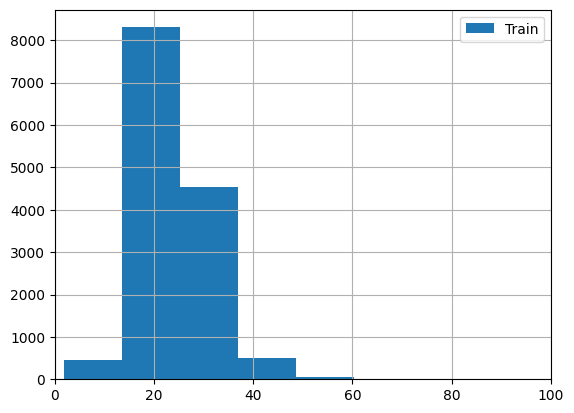

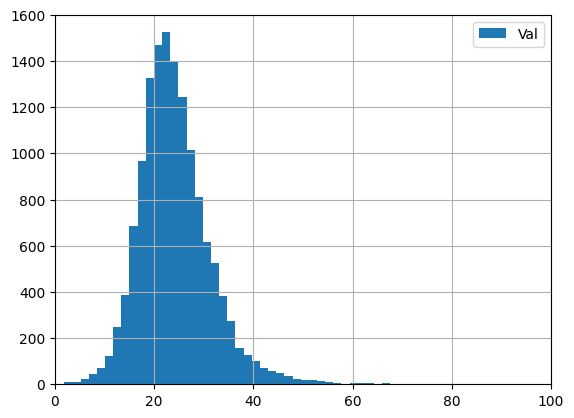

In [8]:
plt.figure()
res_metric.query("n_train > 30")['mape_train'].hist(bins=20, label='Train')
plt.xlim(0, 100)   # 👈 set your desired range
plt.legend()

plt.figure()
res_metric.query("n_train > 30")['mape_val'].hist(bins=5000, label='Val')
plt.xlim(0, 100)   # 👈 same here
plt.legend()

plt.show()


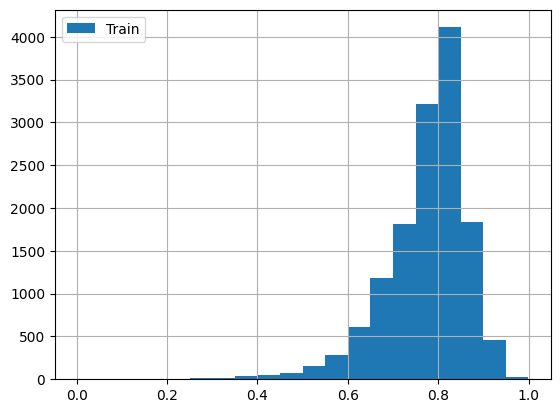

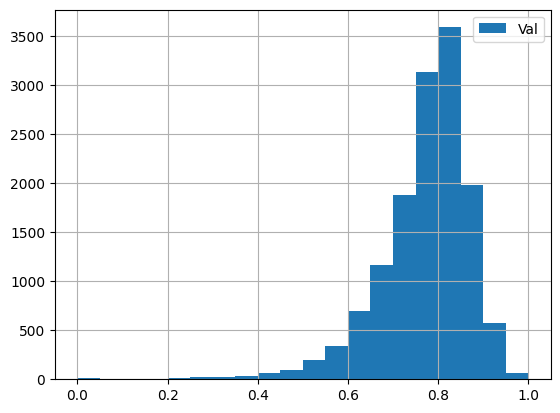

In [9]:
plt.figure()
res_metric.query("n_train >  30")['r2_train'].hist(bins=20, label='Train')
plt.legend()
plt.figure()
res_metric.query("n_train >  30")['r2_val'].hist(bins=20, label='Val')
plt.legend()
plt.show()

In [44]:
plt.close()

In [12]:
res_metric['site_id'].nunique()

13269

In [16]:
res_metric.query('mape_val > 60').sort_values('mape_train', ascending=False)

,site_id,n_train,r2_train,mape_train,rmse_train,mae_train,bias_train,n_val,r2_val,mape_val,rmse_val,mae_val,bias_val
1564,1230143344,43,0.039941,235.644441,8.429098,3.325325,-3.325325,7,0.094633,8220.508873,171.200174,106.091068,-106.091068
204,1530734882,1601,0.234941,76.568833,0.881505,0.607178,-0.607178,250,0.125426,100.259951,1.054557,0.716134,-0.716134
4890,884472414,7368,0.192927,75.967736,1.462540,1.158495,-1.158495,1781,0.180291,69.809536,1.397718,1.057559,-1.057559
5685,1034775128,3643,0.599705,70.665989,2.067969,1.672554,-1.672554,910,0.514606,68.437302,2.105214,1.710723,-1.710723
1426,180462074,3232,0.272247,69.503333,0.740804,0.530721,-0.530721,930,0.294105,63.878032,0.685893,0.481918,-0.481918
4274,1542534882,4647,0.320339,68.185903,2.334428,1.874665,-1.874665,1266,0.321569,69.270162,2.325459,1.899088,-1.899088
1424,156860538,3771,0.290316,64.097902,1.289028,0.968703,-0.968703,1000,0.265074,68.060824,1.302854,0.988055,-0.988055
3815,129686942,9642,0.222223,62.240842,1.722530,1.390349,-1.390349,2563,0.233229,61.818125,1.733350,1.392106,-1.392106
4105,1998524318,3966,0.360398,58.337469,4.092446,3.258044,-3.258044,1040,0.342657,62.892048,4.143498,3.352225,-3.352225
3862,644355266,632,0.303311,57.724127,1.467131,0.996044,-0.996044,83,0.243955,76.734793,1.454116,1.125319,-1.125319


In [15]:
res_metric[res_metric['site_id'] == 1792599725].sort_values('mape_train', ascending=False)

,site_id,tod_bin,n_train,r2_train,mape_train,rmse_train,mae_train,bias_train,n_val,r2_val,mape_val,rmse_val,mae_val,bias_val
852350,1792599725,05:50:00,11,0.007602,1779.213147,19.661755,19.523840,-19.523840,4,0.031975,1938.428859,17.886903,17.570118,-17.570118
852319,1792599725,08:55:00,193,0.684526,191.091778,4.710677,4.585651,-4.585651,54,0.743000,181.930681,4.526764,4.402945,-4.402945
851246,1792599725,09:35:00,190,0.696516,188.388988,4.455346,4.368405,-4.368405,48,0.795810,154.215147,4.299664,4.233378,-4.233378
900704,1792599725,09:45:00,186,0.700647,188.347683,4.628711,4.552433,-4.552433,46,0.786101,165.318056,4.575753,4.502781,-4.502781
852324,1792599725,09:30:00,195,0.711272,187.009804,4.542519,4.451633,-4.451633,47,0.780676,177.227467,4.442598,4.364694,-4.364694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851259,1792599725,16:50:00,44,0.482472,10.911433,0.302533,0.222834,-0.222834,9,0.156917,10.109431,0.311043,0.234510,-0.234510
892646,1792599725,16:55:00,30,0.110431,2.395349,0.325488,0.245713,-0.245713,8,0.004838,NaN,0.369365,0.328039,-0.328039
843285,1792599725,17:05:00,1,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN
851261,1792599725,05:45:00,7,0.133137,NaN,9.025569,9.023719,-9.023719,2,1.000000,NaN,9.037209,9.036618,-9.036618


In [16]:
iceberg_sql("""select  * 
            from pv_ghi_model
            where site_id=1792599725
            order by tod_bin """)[50:100]

OperationalError: (trino.exceptions.TrinoConnectionError) failed to execute: HTTPConnectionPool(host='trino.ciccada', port=8080): Max retries exceeded with url: /v1/statement (Caused by NameResolutionError("<urllib3.connection.HTTPConnection object at 0x7714e6f49190>: Failed to resolve 'trino.ciccada' ([Errno -2] Name or service not known)"))
[SQL: SET SESSION task_concurrency = 1]
(Background on this error at: https://sqlalche.me/e/20/e3q8)